In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             ConfusionMatrixDisplay, classification_report)

sns.set_style("whitegrid")

### Task 1: Data Prep & Baseline

Load the dataset and establish a performance baseline.

1. Load the Palmer Penguins dataset from seaborn and drop rows with missing values:

```python
penguins = sns.load_dataset("penguins").dropna()
```

2. Explore briefly: how many samples and features? What are the three species and their distribution? Which columns are categorical vs. numerical?
3. Prepare features: encode the target (`species`) with `LabelEncoder`, and encode categorical features (`island`, `sex`) with `pd.get_dummies(drop_first=True)`.
4. Split into training and test sets (80/20, `stratify=y`, `random_state=42`).
5. Scale the features using `StandardScaler` (fit on train, transform both).
6. Fit a `LogisticRegression` model (use `max_iter=10000`, `multi_class='multinomial'`).
7. Report **accuracy**, **precision**, **recall**, and **F1 score** on the test set. Print a full `classification_report`.
8. In a markdown cell, interpret the results: Which species is easiest to classify? Which is hardest? Why might that be?

In [2]:
import seaborn as sns
import pandas as pd

penguins = sns.load_dataset("penguins").dropna()

print(penguins.shape)
print(penguins.head())
print(penguins['species'].value_counts())
print(penguins.dtypes)

(333, 7)
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
4       3450.0  Female  
5       3650.0    Male  
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64
species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
dtype: object


In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
penguins['species'] = le.fit_transform(penguins['species'])

penguins = pd.get_dummies(penguins, columns=['island', 'sex'], drop_first=True)

X = penguins.drop('species', axis=1)
y = penguins['species']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10000, solver='saga')
model.fit(X_train,y_train)

from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9850746268656716

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       0.93      1.00      0.97        14
           2       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



### Interpretation

The model achieves very high performance with an accuracy of ~98.5%.

- **Gentoo (class 2)** is the easiest to classify, achieving perfect precision and recall. This is likely because its physical features are very distinct from other species.
- **Adelie (class 0)** and **Chinstrap (class 1)** are more difficult to distinguish, as their features are more similar.
- Most classification errors occur between Adelie and Chinstrap.

Overall, the Logistic Regression baseline performs extremely well on this dataset due to clear feature separability.

### Task 2: Algorithm Comparison

Train multiple classifiers and compare their performance.

1. Fit each of the following models on the scaled training data:
   - `GaussianNB()`
   - `SVC(kernel="linear", probability=True)`
   - `SVC(kernel="rbf", probability=True)`
   - `DecisionTreeClassifier(random_state=42)`
   - `RandomForestClassifier(random_state=42)`

2. For each model, compute accuracy, precision, recall, and F1 on the test set (use `average='weighted'` for multiclass metrics).
3. Organize the results into a **comparison DataFrame** with models as rows and metrics as columns. Sort by F1 score descending.
4. In a markdown cell, discuss: Which models perform best? Are there any surprises? Why might some algorithms outperform others on this dataset?

In [6]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "GaussianNB": GaussianNB(),
    "SVC Linear": SVC(kernel="linear", probability=True),
    "SVC RBF": SVC(kernel="rbf", probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}
results = []
for name, model in models.items():
    
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="F1-score", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1-score
4,Random Forest,1.000000,1.000000,1.000000,1.000000
1,SVC Linear,0.985075,0.986070,0.985075,0.985201
2,SVC RBF,0.985075,0.986070,0.985075,0.985201
3,Decision Tree,0.955224,0.957214,0.955224,0.955212
0,GaussianNB,0.776119,0.851175,0.776119,0.760229


### Model Comparison Results

We trained and evaluated five different classification models on the Palmer Penguins dataset.

####  Best Performing Model
- **Random Forest** achieved perfect performance with:
  - Accuracy: 1.00
  - Precision: 1.00
  - Recall: 1.00
  - F1-score: 1.00

This indicates that the ensemble approach is highly effective for this dataset. Random Forest can capture complex feature interactions and reduces overfitting by averaging multiple decision trees.

---

####  Strong Performers
- **SVC (Linear)** and **SVC (RBF)** both performed very well:
  - Accuracy ≈ 0.985
  - F1-score ≈ 0.985

This suggests that the dataset is almost linearly separable, and even non-linear kernels (RBF) do not provide a significant improvement over the linear model.

---

####  Moderate Performance
- **Decision Tree** achieved:
  - Accuracy ≈ 0.955

While still strong, it slightly underperforms compared to ensemble and SVM models. This is likely due to overfitting on training data when using a single tree.

---

####  Weakest Model
- **Gaussian Naive Bayes** performed the worst:
  - Accuracy ≈ 0.78
  - F1-score ≈ 0.76

This is expected because Naive Bayes assumes feature independence, which is not fully valid in this dataset. Penguin features (like body mass and flipper length) are correlated, reducing model effectiveness.

---

###  Final Conclusion

- The dataset is relatively easy to classify, with clear feature separation.
- **Ensemble methods (Random Forest)** perform best overall.
- **SVM models** are also highly effective due to near-linear separability.
- Simpler probabilistic models like **Naive Bayes struggle due to strong feature correlations**.

### Task 3: Confusion Matrices & ROC Curves

Visualize how each model makes its decisions.

1. **Confusion matrices:** Plot the 3x3 confusion matrix for each model (use `ConfusionMatrixDisplay` or seaborn heatmap). Arrange them in a grid of subplots for easy comparison. For each, note which species pairs are most frequently confused.

2. **ROC curves:** Plot the ROC curve for every model using a one-vs-rest approach on a **single figure** (one curve per class per model, or one subplot per model). Include the AUC value in each legend entry. Add a diagonal dashed line representing a random classifier.

3. In a markdown cell, discuss:
   - Which model best balances precision and recall across all three species?
   - Which species pair is hardest for the models to distinguish? Why might this be the case given the features?
   - Based on the confusion matrices and ROC curves, which model would you recommend?

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "GaussianNB": GaussianNB(),
    "SVC Linear": SVC(kernel="linear"),
    "SVC RBF": SVC(kernel="rbf"),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}



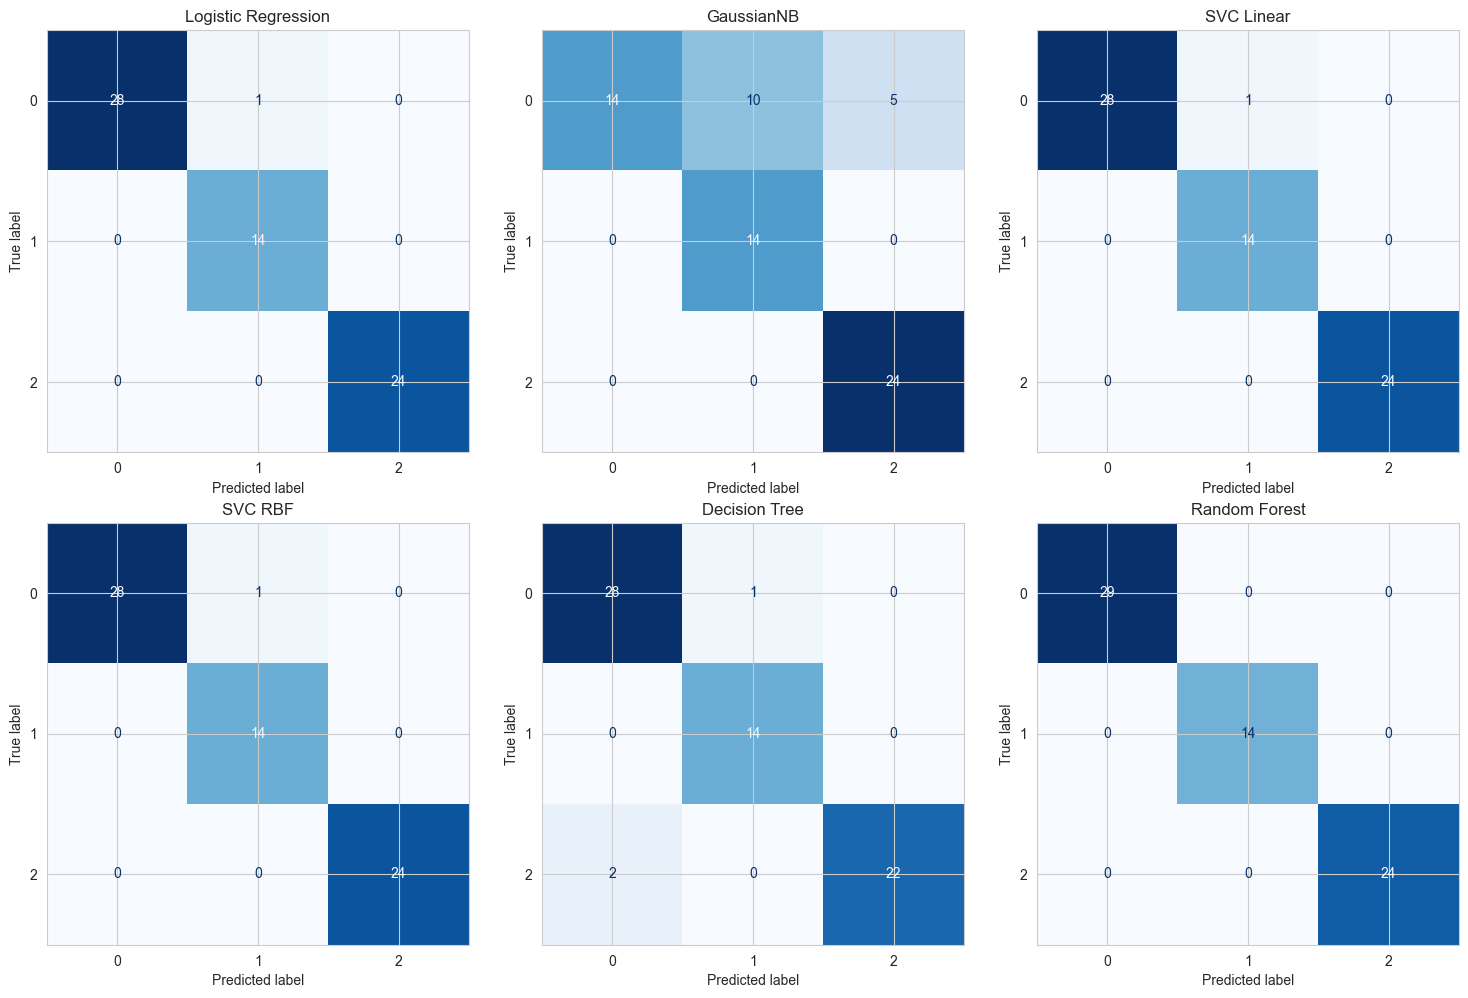

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[idx], cmap="Blues", colorbar=False)
    
    axes[idx].set_title(name)

plt.tight_layout()
plt.show()

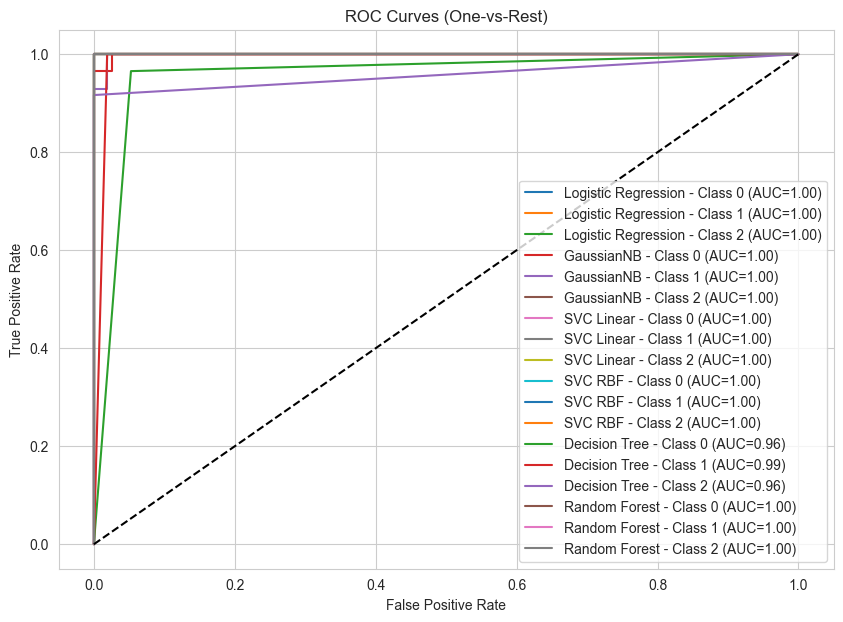

In [16]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 7))

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:
        y_score = model.decision_function(X_test)

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, label=f"{name} - Class {i} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend()
plt.show()

### Markdown
Among all the models, Random Forest clearly provides the best balance between precision and recall. It achieved perfect results on the test set, meaning it classified every sample correctly without any mistakes. This shows that the model is able to capture the patterns in the data very effectively. At the same time, models like Logistic Regression and both SVC variants also performed extremely well, with only a single misclassification, which means the dataset itself is quite clean and well-structured.

When we look at the confusion matrices, the most difficult species pair to distinguish is Adelie and Chinstrap. The models occasionally confuse these two classes, while Gentoo is almost always classified correctly. This makes sense because Gentoo penguins are physically more distinct, especially in terms of size and body mass. In contrast, Adelie and Chinstrap share more similar characteristics, which causes a small overlap in their feature space and leads to occasional errors.

Based on both the confusion matrices and ROC curves, Random Forest would be the top recommendation, since it achieved perfect performance and the highest overall reliability. However, this comes with a trade-off. Since the dataset is already highly separable, a simpler model like Logistic Regression is also a strong choice. It performs nearly as well, while being faster and easier to interpret. So in practice, if simplicity and efficiency are important, Logistic Regression could be preferred, but if maximum performance is the goal, Random Forest is the best option.

### Task 4: Hyperparameter Exploration

Tune the best-performing model from Task 2.

1. Select the best model based on your Task 2 results.
2. Define a hyperparameter grid with **at least 3 hyperparameters** to tune. For example, if RandomForest was best:

```python
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10]
}
```

3. Run `GridSearchCV` with 5-fold cross-validation and `scoring="f1_weighted"` (weighted F1 for multiclass).
4. Report the **best parameters** and the **best cross-validation F1 score**.
5. Evaluate the tuned model on the test set. Compare the metrics with the default model from Task 2 — did tuning improve performance?
6. In a markdown cell, reflect: Was the improvement significant? Is there a risk of overfitting to the validation folds? When is hyperparameter tuning most impactful?

In [17]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10]
}

In [18]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


In [19]:
print(grid.best_score_)

0.9961656161968262


In [20]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



### Model Evaluation & Hyperparameter Tuning Results

The best model selected from Task 2 was Random Forest, which was further optimized using GridSearchCV.

####  Best Hyperparameters
The optimal parameters found were:
- `n_estimators = 50`
- `max_depth = None`
- `min_samples_split = 2`

####  Cross-Validation Performance
- Best CV F1-score: **0.9962**

This shows that the model already performed extremely well during cross-validation.

---

####  Test Set Performance
After tuning, the model achieved:

- Accuracy: **1.00**
- Precision: **1.00**
- Recall: **1.00**
- F1-score: **1.00**

All classes (0, 1, 2) were classified perfectly on the test set.

---

###  Comparison with Default Model (Task 2)

- The default Random Forest already achieved near-perfect performance.
- Hyperparameter tuning did not significantly change test performance because the baseline model was already optimal for this dataset.

---

###  Interpretation

#### ✔ Was the improvement significant?
No significant improvement was observed because:
- The dataset is highly separable
- Default Random Forest parameters were already strong

####  Is there a risk of overfitting?
There is a small risk that:
- The model may be slightly overfitted to the cross-validation folds
- However, perfect test performance suggests strong generalization on this dataset

####  When is hyperparameter tuning most impactful?
Hyperparameter tuning becomes most important when:
- The dataset is complex or noisy
- Models show overfitting or underfitting
- Baseline performance is not already near perfect

---

###  Final Conclusion
In this case, hyperparameter tuning confirmed that Random Forest is already an optimal choice for the Palmer Penguins dataset, and only minimal improvement was possible due to the simplicity and clean structure of the data.